In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../Data_Pre-processing/clean_data.csv")

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
RF_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

RF_model.fit(X_train, y_train)
y_pred = RF_model.predict(X_test)

print("Accuracy=", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy= 0.8369565217391305
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



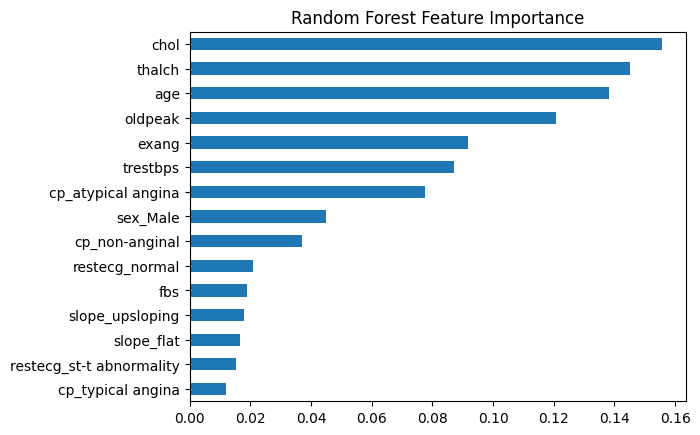

In [11]:
importances = RF_model.feature_importances_
features = X_train.columns

pd.Series(importances, index=features).sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

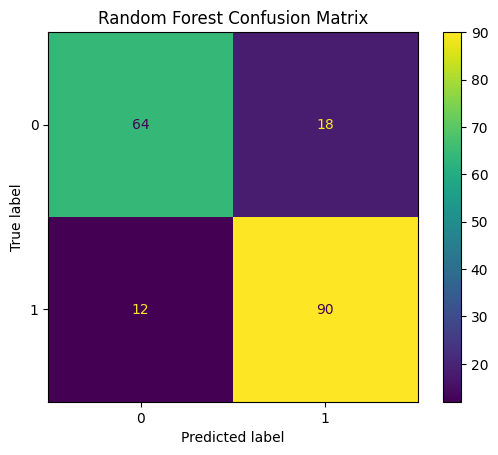

In [12]:
cm_rf = confusion_matrix(y_test, RF_model.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()